# Pipeline Results — Model Selection on 35 Real SKUs

This looks at what `src/pipeline.py` actually decided when it ran the
full classify → backtest → select loop on the real M5 sample:
`data/processed/model_evaluation.csv` (one row per SKU, every method's
score, and the final decision) and `data/processed/selected_forecasts.csv`
(the selected method's actual forecast vs. actual, month by month).

Nothing here is simulated — every number below is exactly what your own
pipeline run produced.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

evaluation = pd.read_csv(config.PROCESSED_DIR / "model_evaluation.csv")
forecasts = pd.read_csv(config.PROCESSED_DIR / "selected_forecasts.csv", parse_dates=["Date"])

(config.PROJECT_ROOT / "outputs" / "figures").mkdir(parents=True, exist_ok=True)

print(f"{len(evaluation)} SKUs evaluated, {evaluation['Short_History_Flag'].sum()} short-history, "
      f"{evaluation['Fallback_Used'].sum()} fallback, {evaluation['Tracking_Signal_Guardrail_Applied'].sum()} guardrail-overridden")
evaluation.head()

35 SKUs evaluated, 0 short-history, 0 fallback, 3 guardrail-overridden


,SKU,Product_Family,ADI,CV2,Demand_Class,n_months,Short_History_Flag,n_train,n_test,SMA_Window,...,TrackingSignal_SMA,WMAPE_SES,Bias_SES,TrackingSignal_SES,WMAPE_Holt_Winters,Bias_Holt_Winters,TrackingSignal_Holt_Winters,WMAPE_Croston,Bias_Croston,TrackingSignal_Croston
0,FOODS_1_124,FOODS_1,1.300000,0.239768,Smooth,65,False,52,13,3,...,-2.826087,55.117099,-6.640353,-1.566204,58.038629,-1.007528,-0.225675,55.227329,-26.141774,-6.153531
1,FOODS_1_128,FOODS_1,1.048387,0.359552,Smooth,65,False,52,13,12,...,-1.850277,49.754187,17.912958,4.680379,34.912274,-4.639250,-1.727480,40.268590,-0.303269,-0.097905
2,FOODS_1_135,FOODS_1,1.382979,0.253365,Intermittent,65,False,52,13,6,...,-1.880922,70.075125,-12.803477,-2.375240,58.662722,-12.615565,-2.795683,71.987136,-16.466735,-2.973692
3,FOODS_1_185,FOODS_1,1.015625,0.213441,Smooth,65,False,52,13,12,...,-5.534532,43.644311,-4.656452,-1.386982,46.205707,-9.724030,-2.735861,36.745748,-16.131881,-5.707176
4,FOODS_2_045,FOODS_2,1.911765,0.181355,Intermittent,65,False,52,13,3,...,-5.264463,27.874976,-6.150231,-2.868271,25.731332,-4.477880,-2.262318,68.286993,-63.904397,-12.165672


In [2]:
FAMILY_PALETTE = {"FOODS_1": "#4C72B0", "FOODS_2": "#DD8452", "FOODS_3": "#55A868"}
METHOD_PALETTE = {"SMA": "#4C72B0", "SES": "#DD8452", "Holt-Winters": "#55A868", "Croston": "#C44E52"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E3E3",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
})

## 1. Which method actually won, and how often

Not a foregone conclusion — the model-selection engine picks per SKU
based on each SKU's own backtest, so this distribution is an outcome of
35 independent decisions, not a preset split.

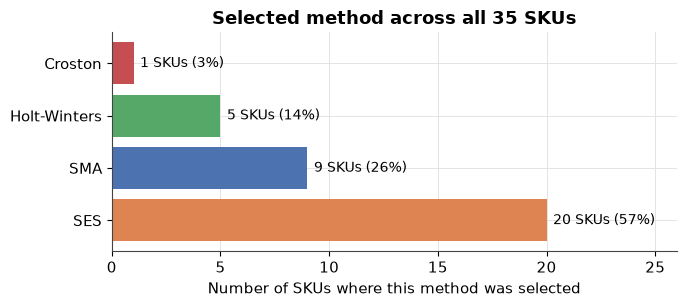

In [3]:
win_counts = evaluation["Selected_Method"].value_counts()
win_counts = win_counts.reindex(["SES", "SMA", "Holt-Winters", "Croston"]).fillna(0)

fig, ax = plt.subplots(figsize=(7, 3.2))
bars = ax.barh(win_counts.index, win_counts.values,
                color=[METHOD_PALETTE[m] for m in win_counts.index])
for bar, val in zip(bars, win_counts.values):
    pct = val / len(evaluation) * 100
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2, f"{int(val)} SKUs ({pct:.0f}%)",
            va="center", fontsize=10)
ax.set_xlim(0, win_counts.max() * 1.3)
ax.set_xlabel("Number of SKUs where this method was selected")
ax.set_title("Selected method across all 35 SKUs")
fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "method_win_rate.png", dpi=150)
plt.show()

## 2. Forecast accuracy by demand class

Shown as individual points, not a box plot — several classes have very
few SKUs in this sample (`Erratic` has exactly 1), and a box plot on n=1
would visually imply a spread that doesn't exist. Each dot is one SKU's
`Selected_WMAPE`; the black diamond is the class mean, labeled with its
sample size so it's never read as more robust than it is.

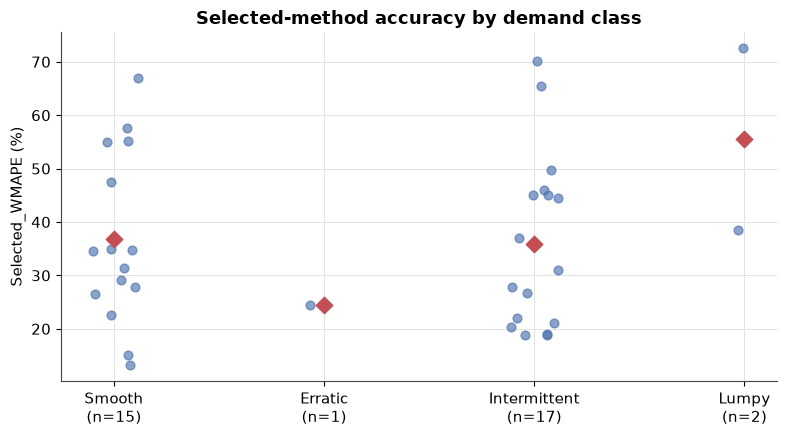

In [4]:
rng = np.random.default_rng(config.RANDOM_SEED)
class_order = ["Smooth", "Erratic", "Intermittent", "Lumpy"]
class_order = [c for c in class_order if c in evaluation["Demand_Class"].unique()]

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, cls in enumerate(class_order):
    vals = evaluation.loc[evaluation["Demand_Class"] == cls, "Selected_WMAPE"].dropna()
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color="#4C72B0", alpha=0.65, s=40, zorder=3)
    ax.scatter([i], [vals.mean()], color="#C44E52", marker="D", s=70, zorder=4)

ax.set_xticks(range(len(class_order)))
ax.set_xticklabels([f"{c}\n(n={sum(evaluation['Demand_Class'] == c)})" for c in class_order])
ax.set_ylabel("Selected_WMAPE (%)")
ax.set_title("Selected-method accuracy by demand class")
fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "wmape_by_class.png", dpi=150)
plt.show()

## 3. Best, worst, and a guardrail case — forecast vs. actual

Three specific SKUs, picked by their actual `Selected_WMAPE` (not
hand-picked for a nice-looking chart): the best forecast, the worst, and
one where the tracking-signal guardrail overrode the top WMAPE pick.

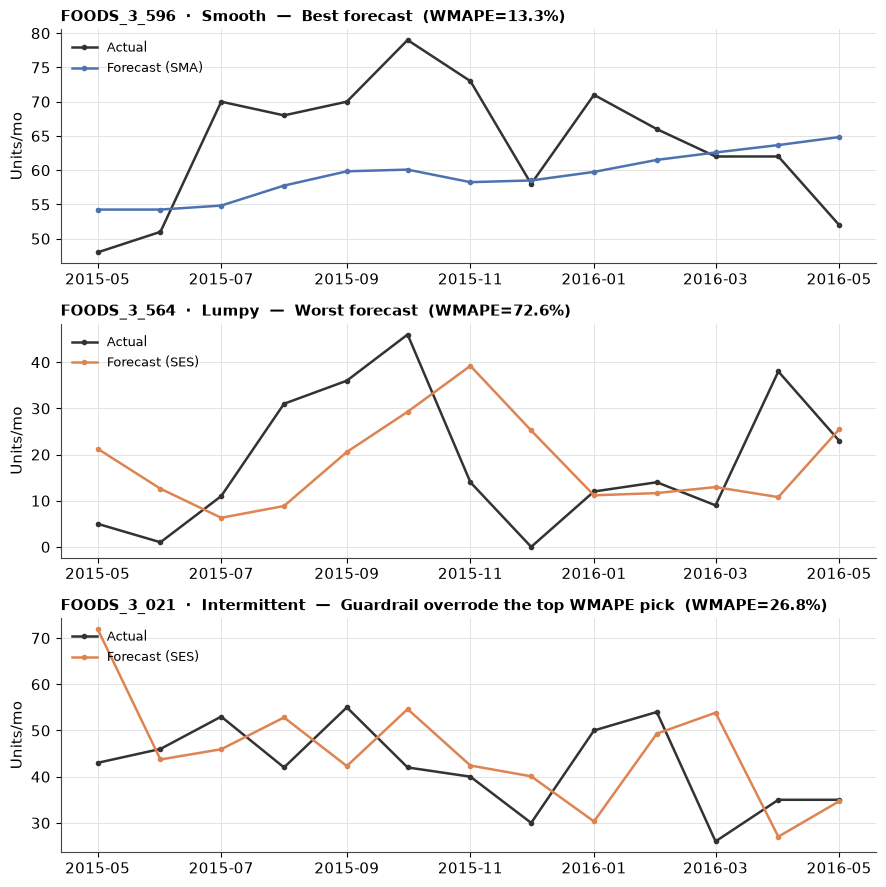

In [5]:
ranked = evaluation.sort_values("Selected_WMAPE")
best_sku = ranked.iloc[0]
worst_sku = ranked.iloc[-1]
guardrail_rows = evaluation[evaluation["Tracking_Signal_Guardrail_Applied"]]
guardrail_sku = guardrail_rows.iloc[0] if len(guardrail_rows) else None

examples = [(best_sku, "Best forecast"), (worst_sku, "Worst forecast")]
if guardrail_sku is not None:
    examples.append((guardrail_sku, "Guardrail overrode the top WMAPE pick"))

fig, axes = plt.subplots(len(examples), 1, figsize=(9, 3 * len(examples)), sharex=False)
if len(examples) == 1:
    axes = [axes]

for ax, (row, label) in zip(axes, examples):
    sku_fc = forecasts[forecasts["SKU"] == row["SKU"]].sort_values("Date")
    ax.plot(sku_fc["Date"], sku_fc["Actual"], color="#333333", linewidth=1.8, marker="o", markersize=3, label="Actual")
    ax.plot(sku_fc["Date"], sku_fc["Forecast"], color=METHOD_PALETTE.get(row["Selected_Method"], "#999999"),
            linewidth=1.8, marker="o", markersize=3, label=f"Forecast ({row['Selected_Method']})")
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.set_title(f"{row['SKU']}  ·  {row['Demand_Class']}  —  {label}  (WMAPE={row['Selected_WMAPE']:.1f}%)",
                 loc="left", fontsize=10.5)
    ax.set_ylabel("Units/mo")

fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "forecast_vs_actual_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Making the guardrail's trade-off visible

For every SKU where the tracking-signal guardrail actually overrode the
lowest-WMAPE method, this shows exactly what was traded away: a slightly
higher WMAPE in exchange for a tracking signal back inside the
control limit. This is the auditability the guardrail is meant to
provide — the decision isn't hidden inside a single accuracy number.

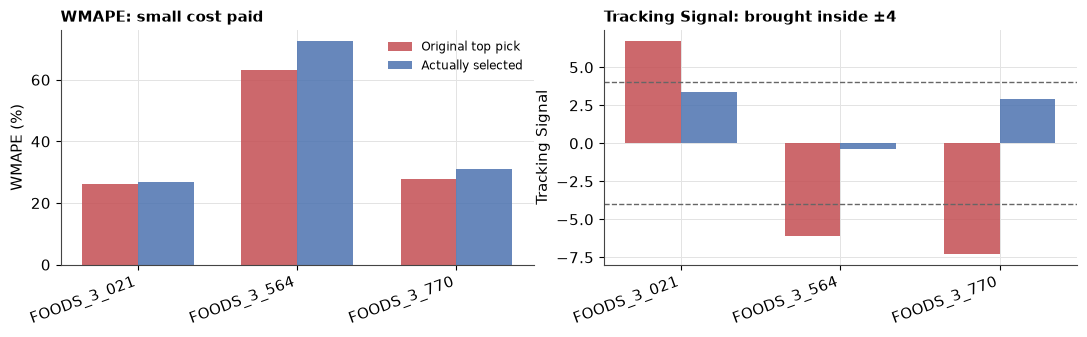

In [6]:
if len(guardrail_rows):
    method_cols = {"SMA": "WMAPE_SMA", "SES": "WMAPE_SES", "Holt-Winters": "WMAPE_Holt_Winters", "Croston": "WMAPE_Croston"}
    ts_cols = {"SMA": "TrackingSignal_SMA", "SES": "TrackingSignal_SES", "Holt-Winters": "TrackingSignal_Holt_Winters", "Croston": "TrackingSignal_Croston"}

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    x = np.arange(len(guardrail_rows))
    width = 0.35

    selected_wmape = [r[method_cols[r["Selected_Method"]]] for _, r in guardrail_rows.iterrows()]
    runnerup_wmape = [r[method_cols[r["Runner_Up_Method"]]] for _, r in guardrail_rows.iterrows()]
    selected_ts = [r[ts_cols[r["Selected_Method"]]] for _, r in guardrail_rows.iterrows()]
    runnerup_ts = [r[ts_cols[r["Runner_Up_Method"]]] for _, r in guardrail_rows.iterrows()]

    axes[0].bar(x - width/2, runnerup_wmape, width, label="Original top pick", color="#C44E52", alpha=0.85)
    axes[0].bar(x + width/2, selected_wmape, width, label="Actually selected", color="#4C72B0", alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(guardrail_rows["SKU"], rotation=20, ha="right")
    axes[0].set_ylabel("WMAPE (%)"); axes[0].set_title("WMAPE: small cost paid", loc="left", fontsize=11)
    axes[0].legend(frameon=False, fontsize=8.5)

    axes[1].bar(x - width/2, runnerup_ts, width, color="#C44E52", alpha=0.85)
    axes[1].bar(x + width/2, selected_ts, width, color="#4C72B0", alpha=0.85)
    axes[1].axhline(config.TRACKING_SIGNAL_CONTROL_LIMIT, color="#666666", linestyle="--", linewidth=1)
    axes[1].axhline(-config.TRACKING_SIGNAL_CONTROL_LIMIT, color="#666666", linestyle="--", linewidth=1)
    axes[1].set_xticks(x); axes[1].set_xticklabels(guardrail_rows["SKU"], rotation=20, ha="right")
    axes[1].set_ylabel("Tracking Signal"); axes[1].set_title(f"Tracking Signal: brought inside ±{config.TRACKING_SIGNAL_CONTROL_LIMIT:.0f}", loc="left", fontsize=11)

    fig.tight_layout()
    fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "guardrail_tradeoff.png", dpi=150)
    plt.show()
else:
    print("No guardrail overrides in this run.")

## 5. SMA window choice isn't one-size-fits-all

`select_sma_window` picks 3, 6, or 12 months independently for every SKU
via its own nested backtest. If every SKU ended up with the same window,
that would suggest the per-SKU selection wasn't doing anything real.

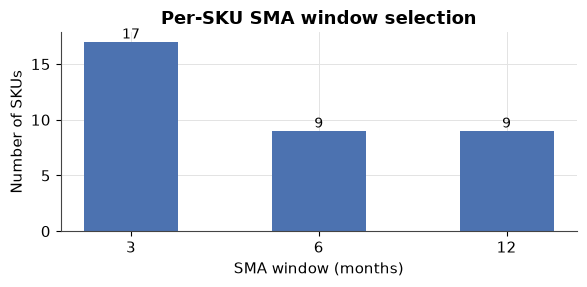

In [7]:
window_counts = evaluation["SMA_Window"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(window_counts.index.astype(str), window_counts.values, color="#4C72B0", width=0.5)
for i, val in enumerate(window_counts.values):
    ax.text(i, val + 0.3, str(int(val)), ha="center", fontsize=10)
ax.set_xlabel("SMA window (months)")
ax.set_ylabel("Number of SKUs")
ax.set_title("Per-SKU SMA window selection")
fig.tight_layout()
fig.savefig(config.PROJECT_ROOT / "outputs" / "figures" / "sma_window_distribution.png", dpi=150)
plt.show()

## Takeaways

*(Write these yourself from what's actually on screen above — a few
prompts:)*

- Did one method dominate, or was the split closer than you expected?
- Does the WMAPE-by-class chart support "harder demand classes forecast
  worse", or is the sample too thin (especially Erratic/Lumpy) to say
  that confidently?
- Look at the worst-forecast SKU's chart — does the forecast look
  structurally wrong (wrong shape entirely) or just off on magnitude?
- Do you agree with the guardrail's trade-off in section 4, or does the
  WMAPE cost look too high for the tracking-signal benefit gained?